## 1. Import Libraries

In [1]:
import pandas as pd

In [2]:
#load data
df = pd.read_csv("adult.csv")
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education.num   32561 non-null  int64
 5   marital.status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital.gain    32561 non-null  int64
 11  capital.loss    32561 non-null  int64
 12  hours.per.week  32561 non-null  int64
 13  native.country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 6.2 MB


# 2-Splitting the Data

In [3]:
from sklearn.model_selection import train_test_split

# 1. Separate features and target
X = df.drop('income', axis=1)
y = df['income']

# 2. Split data (80% Train, 20% Test) with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

# 3. Verify dataset dimensions
print(f"Total dataset size: {df.shape}")
print(f"X_train size: {X_train.shape}")
print(f"X_test size: {X_test.shape}")

Total dataset size: (32561, 15)
X_train size: (26048, 14)
X_test size: (6513, 14)


#  3-claen & EDA

In [4]:
# 1. Identify categorical columns
categorical_cols = X_train.select_dtypes(include=['object']).columns

# 2. Check unique values and "?" counts in Training set
for col in categorical_cols:
    q_count = (X_train[col] == '?').sum()
    print(f"Column: {col} | Unique: {X_train[col].nunique()} | '?' Count: {q_count}")


Column: workclass | Unique: 9 | '?' Count: 1472
Column: education | Unique: 16 | '?' Count: 0
Column: marital.status | Unique: 7 | '?' Count: 0
Column: occupation | Unique: 15 | '?' Count: 1476
Column: relationship | Unique: 6 | '?' Count: 0
Column: race | Unique: 5 | '?' Count: 0
Column: sex | Unique: 2 | '?' Count: 0
Column: native.country | Unique: 41 | '?' Count: 447


C:\Users\hp\AppData\Local\Temp\ipykernel_17420\3167403939.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include=['object']).columns


In [5]:
import numpy as np

# 1. Replace '?' with NaN
X_train = X_train.replace('?', np.nan)
X_test = X_test.replace('?', np.nan)

# 2. Drop rows with NaN values
X_train = X_train.dropna()
y_train = y_train[X_train.index] # Sync target with cleaned features

X_test = X_test.dropna()
y_test = y_test[X_test.index] # Sync target with cleaned features

# 3. Verify final shapes
print(f"Cleaned X_train shape: {X_train.shape}")
print(f"Cleaned X_test shape: {X_test.shape}")

Cleaned X_train shape: (24148, 14)
Cleaned X_test shape: (6014, 14)


C:\Users\hp\AppData\Local\Temp\ipykernel_1788\3598762760.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, palette='viridis')
C:\Users\hp\AppData\Local\Temp\ipykernel_1788\3598762760.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=y_train, y=X_train['age'], palette='magma')


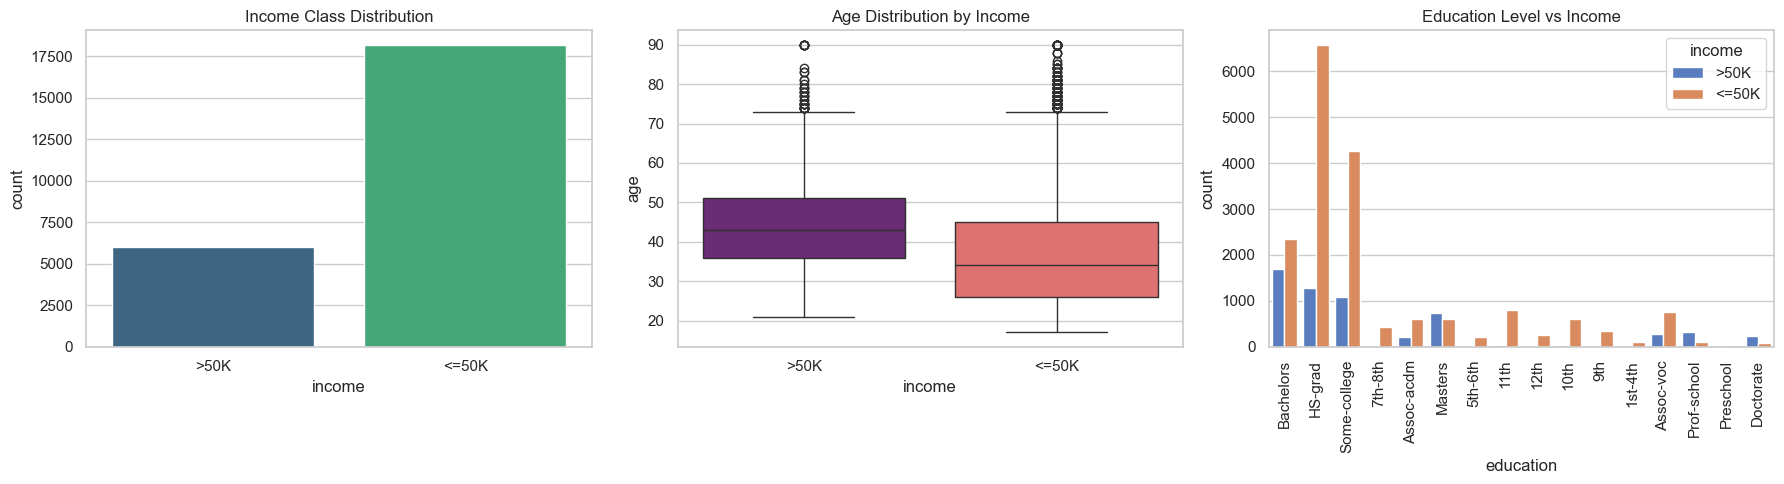

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 5))

# 2. Plot 1: Income Distribution (Check class imbalance)
plt.subplot(1, 3, 1)
sns.countplot(x=y_train, palette='viridis')
plt.title('Income Class Distribution')

# 3. Plot 2: Age vs Income (Numerical vs Categorical)
plt.subplot(1, 3, 2)
sns.boxplot(x=y_train, y=X_train['age'], palette='magma')
plt.title('Age Distribution by Income')

# 4. Plot 3: Education vs Income (Categorical vs Categorical)
plt.subplot(1, 3, 3)
sns.countplot(x=X_train['education'], hue=y_train, palette='muted')
plt.xticks(rotation=90)
plt.title('Education Level vs Income')

plt.tight_layout()
plt.show()

# 4-Preprocessing

In [6]:
#Feature Engineering
# 1. Working Hours Binary
X_train['long_hours'] = (X_train['hours.per.week'] > 40).astype(int)
X_test['long_hours'] = (X_test['hours.per.week'] > 40).astype(int)

# 2. Capital Gain/Loss Binary
X_train['has_gain'] = (X_train['capital.gain'] > 0).astype(int)
X_test['has_gain'] = (X_test['capital.gain'] > 0).astype(int)

X_train['has_loss'] = (X_train['capital.loss'] > 0).astype(int)
X_test['has_loss'] = (X_test['capital.loss'] > 0).astype(int)

# 3. Age Binning
X_train['age_group'] = pd.cut(X_train['age'], bins=[0,25,40,60,100], labels=[0,1,2,3]).astype(int)
X_test['age_group'] = pd.cut(X_test['age'], bins=[0,25,40,60,100], labels=[0,1,2,3]).astype(int)


In [12]:
X_train.info()


<class 'pandas.DataFrame'>
Index: 24148 entries, 11219 to 7468
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             24148 non-null  int64
 1   workclass       24148 non-null  str  
 2   fnlwgt          24148 non-null  int64
 3   education       24148 non-null  str  
 4   education.num   24148 non-null  int64
 5   marital.status  24148 non-null  str  
 6   occupation      24148 non-null  str  
 7   relationship    24148 non-null  str  
 8   race            24148 non-null  str  
 9   sex             24148 non-null  str  
 10  capital.gain    24148 non-null  int64
 11  capital.loss    24148 non-null  int64
 12  hours.per.week  24148 non-null  int64
 13  native.country  24148 non-null  str  
 14  long_hours      24148 non-null  int64
 15  has_gain        24148 non-null  int64
 16  has_loss        24148 non-null  int64
 17  age_group       24148 non-null  int64
dtypes: int64(10), str(8)
memory usage: 5.3 

In [7]:
# 1. Convert categorical variables into dummy/indicator variables (0 and 1)
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

# 2. Align columns: Ensure Test set has the exact same columns as Train set
# If a category exists in Train but not in Test, it adds it with 0s
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# 3. Verify the new number of features
print(f"Total features after One-Hot Encoding: {X_train.shape[1]}")

Total features after One-Hot Encoding: 107


In [8]:
from sklearn.preprocessing import StandardScaler

# 1. Initialize the StandardScaler
scaler = StandardScaler()

# 2. Fit and Transform the Training data
# Note: We calculate Mean and Std ONLY from Training data
X_train_scaled = scaler.fit_transform(X_train)

# 3. Transform the Test data using the same Mean and Std
X_test_scaled = scaler.transform(X_test)



In [20]:
X_train.head()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,long_hours,has_gain,has_loss,age_group,...,native.country_Portugal,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia
11219,34,176831,13,0,0,40,0,0,0,1,...,False,False,False,False,False,False,False,True,False,False
28304,24,217602,9,0,0,60,1,0,0,0,...,False,False,False,False,False,False,False,True,False,False
30810,39,106347,9,0,0,40,0,0,0,1,...,False,False,False,False,False,False,False,True,False,False
10958,28,82531,10,0,0,40,0,0,0,1,...,False,False,False,False,False,False,False,True,False,False
26814,56,98630,4,0,0,40,0,0,0,2,...,False,False,False,False,False,False,False,True,False,False


In [18]:
# Convert the scaled array back to a DataFrame for viewing
scaled_view = pd.DataFrame(X_train_scaled, columns=X_train.columns)

# Look at the statistics (Notice that mean will be ~0 and std will be 1)
print(scaled_view.describe().round(2))

# Look at the first 5 rows
scaled_view.head()

            age    fnlwgt  education.num  capital.gain  capital.loss  \
count  24148.00  24148.00       24148.00      24148.00      24148.00   
mean      -0.00      0.00           0.00          0.00         -0.00   
std        1.00      1.00           1.00          1.00          1.00   
min       -1.63     -1.66          -3.57         -0.15         -0.22   
25%       -0.79     -0.68          -0.44         -0.15         -0.22   
50%       -0.11     -0.11          -0.05         -0.15         -0.22   
75%        0.66      0.45           1.13         -0.15         -0.22   
max        3.93     12.17           2.30         13.32         10.46   

       hours.per.week  long_hours  has_gain  has_loss  age_group  ...  \
count        24148.00    24148.00  24148.00  24148.00   24148.00  ...   
mean            -0.00       -0.00      0.00     -0.00      -0.00  ...   
std              1.00        1.00      1.00      1.00       1.00  ...   
min             -3.33       -0.66     -0.30     -0.22      

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,long_hours,has_gain,has_loss,age_group,...,native.country_Portugal,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia
0,-0.333851,-0.126859,1.125823,-0.148078,-0.220072,-0.074079,-0.659666,-0.304173,-0.224636,-0.335091,...,-0.035269,-0.059784,-0.019309,-0.048642,-0.039174,-0.025749,-0.024931,0.311109,-0.045092,-0.022298
1,-1.095049,0.256592,-0.439311,-0.148078,-0.220072,1.594705,1.515918,-0.304173,-0.224636,-1.533339,...,-0.035269,-0.059784,-0.019309,-0.048642,-0.039174,-0.025749,-0.024931,0.311109,-0.045092,-0.022298
2,0.046747,-0.789762,-0.439311,-0.148078,-0.220072,-0.074079,-0.659666,-0.304173,-0.224636,-0.335091,...,-0.035269,-0.059784,-0.019309,-0.048642,-0.039174,-0.025749,-0.024931,0.311109,-0.045092,-0.022298
3,-0.790570,-1.013751,-0.048027,-0.148078,-0.220072,-0.074079,-0.659666,-0.304173,-0.224636,-0.335091,...,-0.035269,-0.059784,-0.019309,-0.048642,-0.039174,-0.025749,-0.024931,0.311109,-0.045092,-0.022298
4,1.340783,-0.862340,-2.395728,-0.148078,-0.220072,-0.074079,-0.659666,-0.304173,-0.224636,0.863157,...,-0.035269,-0.059784,-0.019309,-0.048642,-0.039174,-0.025749,-0.024931,0.311109,-0.045092,-0.022298


# 5-PCA (Principal Component Analysis)

In [9]:
from sklearn.decomposition import PCA

# 1. Initialize PCA to retain 95% of the variance
pca = PCA(n_components=0.95)

# 2. Fit and transform the scaled training data
X_train_pca = pca.fit_transform(X_train_scaled)

# 3. Transform the scaled test data
X_test_pca = pca.transform(X_test_scaled)

# 4. Check how many features we have now
print(f"Original feature count: {X_train_scaled.shape[1]}")
print(f"Reduced feature count (95% variance): {pca.n_components_}")

Original feature count: 107
Reduced feature count (95% variance): 86


# 6-(SVM Model Development & Tuning).

In [10]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# 1. Define params (Same as your friend's)
param_grid = {
    'C': [1, 10],
    'gamma': [0.1, 0.01],
    'kernel': ['rbf']
}

# 2. Add scoring='f1_weighted' to handle imbalanced data correctly
grid = GridSearchCV(SVC(), param_grid, cv=3, n_jobs=-1, scoring='f1_weighted')

# 3. Fit on PCA data
grid.fit(X_train_pca, y_train)

print("Best Params:", grid.best_params_)

Best Params: {'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}


Final Accuracy: 0.84

--- Classification Report ---
              precision    recall  f1-score   support

       <=50K       0.87      0.93      0.89      4510
        >50K       0.72      0.57      0.63      1504

    accuracy                           0.84      6014
   macro avg       0.79      0.75      0.76      6014
weighted avg       0.83      0.84      0.83      6014



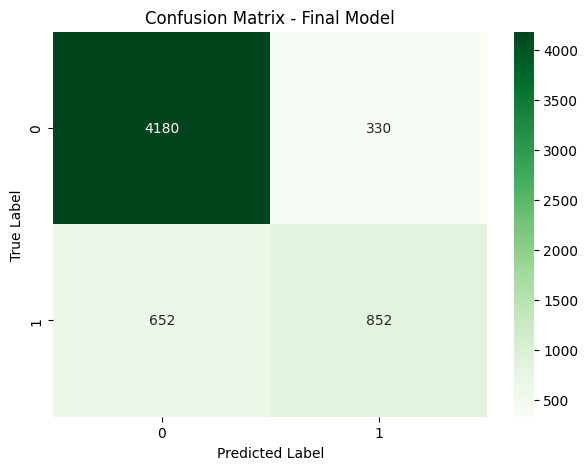

In [11]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Predict labels for the test set
y_pred = grid.predict(X_test_pca)

# 2. Print Accuracy and F1-Score Report
print(f"Final Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

# 3. Visualize Confusion Matrix
plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Final Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [12]:
import joblib

# حفظ كل القطع اللازمة
joblib.dump(grid.best_estimator_, 'svm_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(pca, 'pca_model.pkl')
joblib.dump(X_train.columns.tolist(), 'model_columns.pkl')

print("Model and preprocessing objects saved!")

Model and preprocessing objects saved!


In [13]:
import plotly.express as px
import numpy as np

# 1. نقوم بتقليل الأبعاد لـ 3 فقط من أجل الرسم
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_train_scaled)

# 2. نجهز DataFrame للرسم
plot_df = pd.DataFrame(X_pca_3d, columns=['PC1', 'PC2', 'PC3'])
plot_df['Income'] = y_train.values

# 3. رسم البيانات في فضاء ثلاثي الأبعاد
fig = px.scatter_3d(plot_df, x='PC1', y='PC2', z='PC3',
                    color='Income', 
                    title='3D Visualization of SVM Space',
                    opacity=0.6,
                    color_discrete_map={'<=50K': 'blue', '>50K': 'red'})

fig.show()

In [14]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from sklearn.decomposition import PCA
from sklearn.svm import SVC

# 1. تجهيز الداتا (بناخد عينة عشان الرسم يكون سريع وتفاعلي)
sample_df = X_train_scaled[:1000] # عينة من 1000 نقطة
y_sample = y_train[:1000]

# 2. تقليل الأبعاد لـ 3 أبعاد فقط
pca_3d = PCA(n_components=3)
X_pca = pca_3d.fit_transform(sample_df)

# 3. تدريب موديل بسيط على الـ 3 أبعاد عشان نرسم الـ Boundary
# ملحوظة: بنستخدم C و Gamma اللي طلعوا معانا من الـ Grid Search
svm_3d = SVC(kernel='rbf', C=1, gamma=0.01)
svm_3d.fit(X_pca, y_sample)

# 4. عمل شبكة (Meshgrid) لرسم الغلاف الفاصل
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
z_min, z_max = X_pca[:, 2].min() - 1, X_pca[:, 2].max() + 1

# بناء الشبكة
spacing = 0.5 # كل ما صغر كل ما الرسمة كانت أدق بس أتقل
grid_x, grid_y, grid_z = np.meshgrid(np.arange(x_min, x_max, spacing),
                                     np.arange(y_min, y_max, spacing),
                                     np.arange(z_min, z_max, spacing))

# توقع القيم لكل نقطة في الشبكة
grid_points = np.c_[grid_x.ravel(), grid_y.ravel(), grid_z.ravel()]
decision_values = svm_3d.decision_function(grid_points)
decision_values = decision_values.reshape(grid_x.shape)

# 5. رسم النقط والـ Decision Surface باستخدام Plotly
fig = go.Figure()

# رسم نقط البيانات
for label, color in zip(['<=50K', '>50K'], ['blue', 'red']):
    mask = (y_sample == label).values
    fig.add_trace(go.Scatter3d(x=X_pca[mask, 0], y=X_pca[mask, 1], z=X_pca[mask, 2],
                               mode='markers', name=label,
                               marker=dict(size=3, color=color, opacity=0.6)))

# رسم الغلاف الفاصل (Isosurface)
fig.add_trace(go.Isosurface(
    x=grid_x.flatten(), y=grid_y.flatten(), z=grid_z.flatten(),
    value=decision_values.flatten(),
    isomin=0, isomax=0, # بنرسم عند الصفر بالظبط (الحد الفاصل)
    surface_count=1,
    colorscale='Greys',
    showscale=False,
    caps=dict(x_show=False, y_show=False, z_show=False),
    name='Decision Boundary'
))

fig.update_layout(title="Interactive 3D SVM Decision Boundary",
                  scene=dict(xaxis_title='PC1', yaxis_title='PC2', zaxis_title='PC3'))
fig.show()